# Chapter 172 — Diagonalization

> **Prerequisites:** ch169 (Eigenvectors Intuition), ch170 (Eigenvalues Intuition), ch157 (Matrix Inverse), ch136 (Linear Independence)
> **You will learn:**
> - What it means to diagonalize a matrix
> - When diagonalization is possible (and when it fails)
> - How to use diagonalization to compute matrix powers efficiently
> - The connection between diagonalization and change of basis
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A matrix A is **diagonalizable** if it can be written as:

    A = V Λ V⁻¹

Where:
- V = matrix of eigenvectors (columns)
- Λ = diagonal matrix of eigenvalues
- V⁻¹ = inverse of the eigenvector matrix

This decomposition is powerful because diagonal matrices are trivial to work with: multiply, raise to powers, compute functions of.

**When does it fail?** A matrix is diagonalizable if and only if it has n linearly independent eigenvectors. A matrix that lacks this is called **defective**. Defective matrices require Jordan normal form — not covered here, but the concept is: some eigenvectors are "missing" and get replaced by generalized eigenvectors.

## 2. Intuition & Mental Models

**Change of basis:** Think of diagonalization as finding the "natural coordinate system" for the matrix. In the eigenvector basis, the matrix acts like a simple scaling — no mixing of coordinates.

- V⁻¹: change from standard basis to eigenvector basis
- Λ: apply the transformation (pure scaling in eigenvector coordinates)
- V: change back to standard basis

**Matrix powers:** This is the killer application. A² = VΛV⁻¹·VΛV⁻¹ = VΛ²V⁻¹. The V and V⁻¹ cancel in the middle. So:

    Aⁿ = V Λⁿ V⁻¹

And Λⁿ just raises each diagonal entry to the nth power — trivially fast.

**Computational:** Think of V as a lens. V⁻¹ focuses the input, Λ performs simple scaling, V unfocuses the output. The matrix A is the composition — complex-looking in standard coordinates, trivial in eigenvector coordinates.

## 3. Visualization

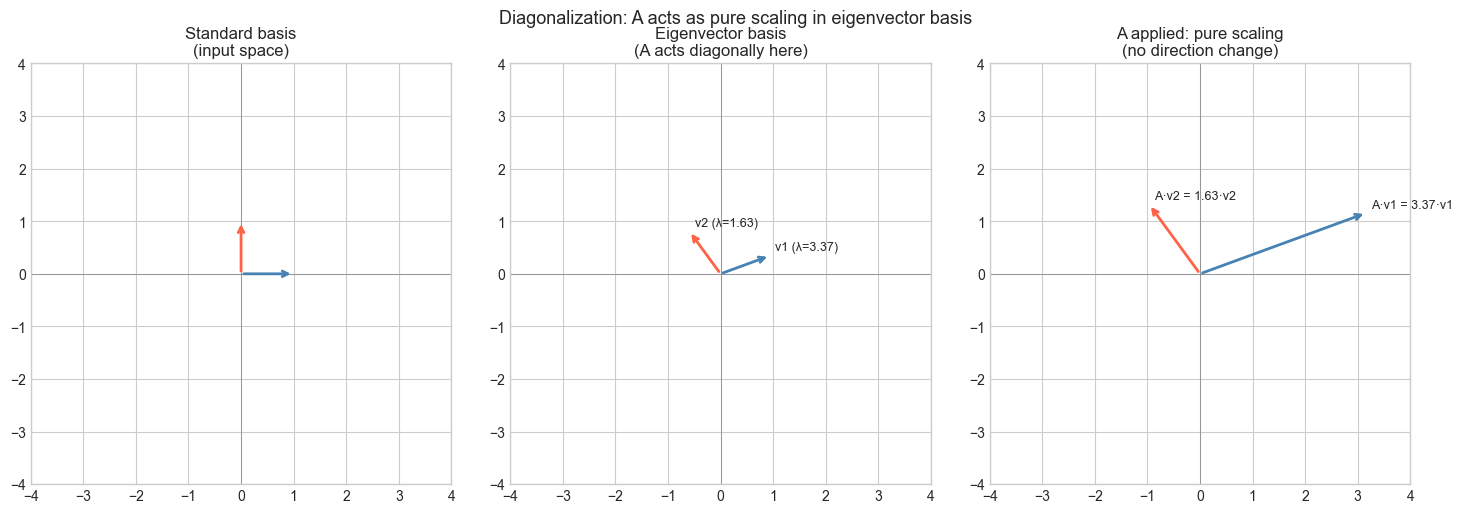

Max reconstruction error: 3.33e-16


In [1]:
# --- Visualization: Diagonalization as change of basis ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

A = np.array([[3.0, 1.0],
              [0.5, 2.0]])

eigvals, V = np.linalg.eig(A)
# Sort by eigenvalue magnitude
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
V = V[:, idx]
Lambda = np.diag(eigvals)
V_inv = np.linalg.inv(V)

# Verify: A ≈ V @ Lambda @ V_inv
A_reconstructed = V @ Lambda @ V_inv

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Show basis vectors in each coordinate system
for ax in axes:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

# Standard basis
e1, e2 = np.array([1,0]), np.array([0,1])
axes[0].annotate('', xy=e1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
axes[0].annotate('', xy=e2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
axes[0].set_title('Standard basis\n(input space)')

# Eigenvector basis (V columns)
v1, v2 = V[:, 0].real, V[:, 1].real
axes[1].annotate('', xy=v1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
axes[1].annotate('', xy=v2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
axes[1].text(v1[0]+.1, v1[1]+.1, f'v1 (λ={eigvals[0]:.2f})', fontsize=9)
axes[1].text(v2[0]+.1, v2[1]+.1, f'v2 (λ={eigvals[1]:.2f})', fontsize=9)
axes[1].set_title('Eigenvector basis\n(A acts diagonally here)')

# A applied to eigenvectors
Av1 = A @ v1
Av2 = A @ v2
axes[2].annotate('', xy=Av1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
axes[2].annotate('', xy=Av2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
axes[2].text(Av1[0]+.1, Av1[1]+.1, f'A·v1 = {eigvals[0]:.2f}·v1', fontsize=9)
axes[2].text(Av2[0]+.1, Av2[1]+.1, f'A·v2 = {eigvals[1]:.2f}·v2', fontsize=9)
axes[2].set_title('A applied: pure scaling\n(no direction change)')

plt.suptitle('Diagonalization: A acts as pure scaling in eigenvector basis', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Max reconstruction error: {np.max(np.abs(A - A_reconstructed)):.2e}")

## 4. Mathematical Formulation

**Eigendecomposition:** If A has n linearly independent eigenvectors v₁, ..., vₙ with eigenvalues λ₁, ..., λₙ:

    A = V Λ V⁻¹

    V = [v₁ | v₂ | ... | vₙ]   (eigenvectors as columns)
    Λ = diag(λ₁, λ₂, ..., λₙ)

**Matrix powers:**

    Aⁿ = V Λⁿ V⁻¹ = V · diag(λ₁ⁿ, ..., λₙⁿ) · V⁻¹

**Matrix exponential:**

    exp(A) = V · diag(exp(λ₁), ..., exp(λₙ)) · V⁻¹

**Symmetric case (spectral theorem):** If A is real symmetric (Aᵀ = A), then:
- All eigenvalues are real
- Eigenvectors are orthogonal
- V is orthogonal: V⁻¹ = Vᵀ → A = V Λ Vᵀ (orthogonal diagonalization)

The symmetric case is numerically better conditioned and appears in covariance matrices, graph Laplacians, and more.

## 5. Python Implementation

In [2]:
# --- Implementation: Matrix functions via diagonalization ---
import numpy as np

def matrix_power_via_diag(A, n):
    """
    Compute A^n using eigendecomposition: A^n = V * diag(lam^n) * V_inv.

    Args:
        A: (k,k) diagonalizable matrix
        n: integer power

    Returns:
        A^n (k,k) array
    """
    eigvals, V = np.linalg.eig(A)
    V_inv = np.linalg.inv(V)
    Lambda_n = np.diag(eigvals**n)  # elementwise power on diagonal
    return (V @ Lambda_n @ V_inv).real


def matrix_exp_via_diag(A):
    """
    Compute the matrix exponential exp(A) = V * diag(exp(lam)) * V_inv.

    Args:
        A: (k,k) diagonalizable matrix

    Returns:
        exp(A) as (k,k) array
    """
    eigvals, V = np.linalg.eig(A)
    V_inv = np.linalg.inv(V)
    Lambda_exp = np.diag(np.exp(eigvals))
    return (V @ Lambda_exp @ V_inv).real


# Test: Fibonacci-like recurrence via matrix power
# [F(n+1), F(n)] = A^n @ [F(1), F(0)] where A = [[1,1],[1,0]]
A_fib = np.array([[1.0, 1.0], [1.0, 0.0]])

print("Fibonacci via matrix power (A^n @ [1, 0]):")
for n in [1, 5, 10, 20]:
    result = matrix_power_via_diag(A_fib, n) @ np.array([1.0, 0.0])
    numpy_result = np.linalg.matrix_power(A_fib, n) @ np.array([1.0, 0.0])
    print(f"  A^{n:2d}: F({n+1}) = {result[0]:.0f}  (numpy: {numpy_result[0]:.0f})")

# Test matrix exponential
A_test = np.array([[1.0, 2.0], [0.0, -1.0]])
exp_A = matrix_exp_via_diag(A_test)
print(f"\nexp(A):\n{exp_A}")

Fibonacci via matrix power (A^n @ [1, 0]):
  A^ 1: F(2) = 1  (numpy: 1)
  A^ 5: F(6) = 8  (numpy: 8)
  A^10: F(11) = 89  (numpy: 89)
  A^20: F(21) = 10946  (numpy: 10946)

exp(A):
[[2.71828183 2.35040239]
 [0.         0.36787944]]


## 6. Experiments

Dominant eigenvalue: 1.1506
→ Population grows


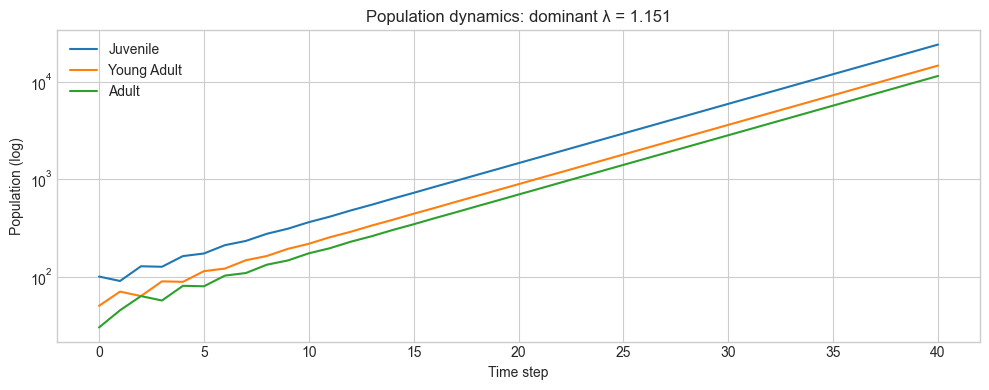

In [3]:
# --- Experiment 1: Long-run behavior via eigenvalues ---
# Hypothesis: For a population model x_{t+1} = A x_t,
#             the dominant eigenvalue predicts long-run growth/decay
# Try changing: the entries of A

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Population transition matrix (e.g., age-structured model)
A = np.array([[0.0, 1.5, 0.5],  # fertility rates
              [0.7, 0.0, 0.0],  # survival: juvenile -> young adult
              [0.0, 0.9, 0.0]]) # survival: young adult -> adult

eigvals, V = np.linalg.eig(A)
dominant_lam = max(eigvals.real)
print(f"Dominant eigenvalue: {dominant_lam:.4f}")
print("→ Population", "grows" if dominant_lam > 1 else "declines")

# Simulate
x = np.array([100.0, 50.0, 30.0])  # initial population
T = 40
history = [x.copy()]
for _ in range(T):
    x = A @ x
    history.append(x.copy())
history = np.array(history)

plt.figure(figsize=(10, 4))
for i, label in enumerate(['Juvenile', 'Young Adult', 'Adult']):
    plt.plot(history[:, i], label=label)
plt.yscale('log')
plt.xlabel('Time step')
plt.ylabel('Population (log)')
plt.title(f'Population dynamics: dominant λ = {dominant_lam:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# --- Experiment 2: When is a matrix NOT diagonalizable? ---
# Hypothesis: A defective matrix has repeated eigenvalues with insufficient eigenvectors
# Try changing: EPSILON (makes matrix more/less defective)

import numpy as np

EPSILON = 0.0  # try: 0.0 (defective), 0.001, 0.1, 1.0

# Near-defective matrix: Jordan block structure
A = np.array([[2.0, 1.0],
              [EPSILON, 2.0]])

eigvals = np.linalg.eigvals(A)
_, V = np.linalg.eig(A)
rank_V = np.linalg.matrix_rank(V)

print(f"EPSILON = {EPSILON}")
print(f"Eigenvalues: {eigvals}")
print(f"Rank of eigenvector matrix: {rank_V}")
print(f"Condition number of V: {np.linalg.cond(V):.2e}")
print("→ Diagonalizable?" , "YES" if rank_V == 2 and EPSILON != 0 else "DEGENERATE")

EPSILON = 0.0
Eigenvalues: [2. 2.]
Rank of eigenvector matrix: 1
Condition number of V: 4.50e+15
→ Diagonalizable? DEGENERATE


## 7. Exercises

**Easy 1.** For the diagonal matrix D = diag(2, 3, 5), what is D¹⁰⁰? Write the answer directly (no code needed), then verify with `matrix_power_via_diag`.

**Easy 2.** Show that if A = VΛV⁻¹, then A⁻¹ = VΛ⁻¹V⁻¹ (assuming A is invertible). Verify with a 3×3 example.

**Medium 1.** A discrete-time linear system x_{t+1} = Ax_t is stable (x→0) if and only if all eigenvalues satisfy |λ| < 1. Write a function `is_stable(A)` and test it on five different matrices including rotation matrices.

**Medium 2.** The covariance matrix of a dataset is always symmetric and positive semidefinite. Generate a dataset of 100 points in 2D, compute its covariance matrix, diagonalize it (use `np.linalg.eigh` for symmetric matrices), and interpret the result geometrically.

**Hard.** Prove that similar matrices (A and B = PAP⁻¹ for invertible P) have the same eigenvalues. Then show that `trace(AB) = trace(BA)` for any A, B using this result.

## 8. Mini Project: Markov Chain Steady State via Diagonalization

Steady state via eigendecomposition: [0.29166667 0.54166667 0.16666667]
Steady state via iteration (t=100): [0.29166667 0.54166667 0.16666667]
Max difference: 8.88e-16


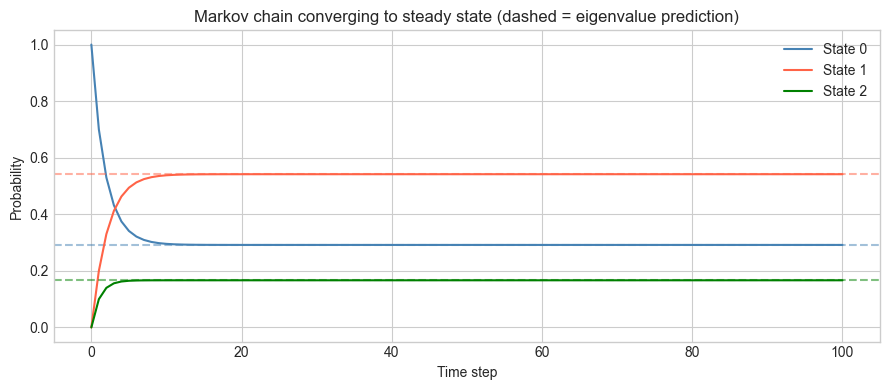

In [5]:
# --- Mini Project: Find steady-state distribution via eigendecomposition ---
# Problem: A Markov chain's transition matrix P has a dominant eigenvalue of 1.
#          The corresponding eigenvector is the steady-state distribution.
# Task: Verify this using diagonalization and compare to iterative simulation.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# 3-state Markov chain: column-stochastic transition matrix
# Entry P[i,j] = probability of going to state i from state j
P = np.array([[0.7, 0.1, 0.2],
              [0.2, 0.8, 0.3],
              [0.1, 0.1, 0.5]])

# Verify column sums = 1
assert np.allclose(P.sum(axis=0), 1.0), "Not a valid stochastic matrix"

# Method 1: Eigendecomposition
eigvals, V = np.linalg.eig(P)
unit_idx = np.argmin(np.abs(eigvals - 1.0))  # eigenvalue ≈ 1
steady_eig = np.abs(V[:, unit_idx].real)
steady_eig /= steady_eig.sum()  # normalize to sum to 1

# Method 2: Iterative simulation
x = np.array([1.0, 0.0, 0.0])  # start in state 0
T = 100
history = [x.copy()]
for _ in range(T):
    x = P @ x
    history.append(x.copy())
history = np.array(history)

# Compare
print("Steady state via eigendecomposition:", steady_eig)
print("Steady state via iteration (t=100):", history[-1])
print(f"Max difference: {np.max(np.abs(steady_eig - history[-1])):.2e}")

plt.figure(figsize=(9, 4))
colors = ['steelblue', 'tomato', 'green']
for i in range(3):
    plt.plot(history[:, i], color=colors[i], label=f'State {i}')
    plt.axhline(steady_eig[i], color=colors[i], ls='--', alpha=0.5)
plt.xlabel('Time step')
plt.ylabel('Probability')
plt.title('Markov chain converging to steady state (dashed = eigenvalue prediction)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Diagonalization A = VΛV⁻¹ expresses A as a change of basis, scaling, and change back.
- Matrix powers become trivial: Aⁿ = VΛⁿV⁻¹ — just raise each eigenvalue to the nth power.
- A matrix is diagonalizable iff it has n linearly independent eigenvectors.
- Real symmetric matrices always diagonalize with orthogonal V (spectral theorem): A = VΛVᵀ.
- Markov chain steady-states, population models, and system stability all reduce to eigenvalue analysis.

**Backward:** Builds on ch169-170 (eigenvectors and eigenvalues) and ch157 (matrix inverse for V⁻¹).

**Forward:**
- ch173 (SVD): the generalization of eigendecomposition to non-square matrices — M = UΣVᵀ
- ch174 (PCA): PCA is diagonalization of the covariance matrix
- ch257 (Markov Chains): Perron-Frobenius theorem — dominant eigenvalue of a positive stochastic matrix is exactly 1

**Going deeper:** The Cayley-Hamilton theorem states that every matrix satisfies its own characteristic polynomial — A² - trace(A)A + det(A)I = 0 for 2×2 matrices. This allows computing matrix functions without full eigendecomposition.